<a href="https://colab.research.google.com/github/Karthikreddy1010/Microplastic_Image_Segmentation/blob/main/Efficientv2B31.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
! unzip /content/archive.zip

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras import mixed_precision
from tensorflow.keras.applications import EfficientNetV2B3
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from sklearn.metrics import precision_score, recall_score, f1_score, mean_absolute_error, mean_squared_error
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
from scipy import stats
import pandas as pd
from skimage.transform import rotate, resize
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# GPU SETUP
# ============================================================================

# Confirm GPU
gpus = tf.config.list_physical_devices('GPU')
assert len(gpus) > 0, "❌ No GPU detected!"
print("✅ GPU detected:", gpus)

# Enable memory growth
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

# Enable mixed precision
mixed_precision.set_global_policy('mixed_float16')
print("✅ Mixed precision enabled")

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

# Configuration
IMG_HEIGHT = 512
IMG_WIDTH = 512
BATCH_SIZE = 4
EPOCHS = 100
PATIENCE = 15

# Paths to your data
TRAIN_IMAGE_DIR = '/content/training/training/Training_original'
TRAIN_MASK_DIR = '/content/training/training/Finalmasks'
VAL_IMAGE_DIR = '/content/val/val/Original'
VAL_MASK_DIR = '/content/val/val/val_100masks'
TEST_IMAGE_DIR = '/content/Testing/Testing/Original'
TEST_MASK_DIR = '/content/Testing/Testing/testing_100masks'

# CSV file paths for ground-truth counts
TRAIN_COUNT_CSV = '/content/GT_train.csv'
VAL_COUNT_CSV = '/content/GT_valid.csv'
TEST_COUNT_CSV = '/content/GT_Test.csv'

# ============================================================================
# 1. FILENAME NORMALIZATION
# ============================================================================

def normalize_name(name):
    """Normalize filename for matching."""
    name = os.path.basename(name)
    name = os.path.splitext(name)[0]
    name = name.replace('_mask', '')
    return name

# ============================================================================
# 2. PREPROCESSING FUNCTIONS
# ============================================================================

def preprocess_mask(mask):
    """Proper mask binarization."""
    mask_binary = (mask > 127).astype(np.float32)
    return mask_binary

# ============================================================================
# 3. PARTICLE COUNTING FUNCTIONS
# ============================================================================

def count_particles_watershed(binary_mask, min_distance=10):
    """Watershed splitting with adaptive marker threshold."""
    if binary_mask.dtype != np.uint8:
        binary_mask = (binary_mask > 0.5).astype(np.uint8)

    if binary_mask.sum() == 0:
        return 0, np.zeros_like(binary_mask)

    # Distance transform
    distance = cv2.distanceTransform(binary_mask, cv2.DIST_L2, 5)

    # Adaptive marker threshold
    if distance.max() > 0:
        non_zero_dist = distance[distance > 0]
        if len(non_zero_dist) > 10:
            thresh_value = np.percentile(non_zero_dist, 70)
        else:
            thresh_value = 0.4 * distance.max()
    else:
        thresh_value = 0

    _, sure_fg = cv2.threshold(distance, thresh_value, 255, 0)
    sure_fg = sure_fg.astype(np.uint8)

    # Watershed setup
    sure_bg = cv2.dilate(binary_mask, np.ones((3, 3), np.uint8), iterations=3)
    unknown = cv2.subtract(sure_bg, sure_fg)

    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0

    # Apply watershed
    binary_rgb = cv2.cvtColor(binary_mask * 255, cv2.COLOR_GRAY2BGR)
    markers = cv2.watershed(binary_rgb, markers)

    # Count markers
    unique_markers = np.unique(markers)
    count = len([m for m in unique_markers if m > 1])

    return count, markers

def count_particles_cc(binary_mask, use_watershed=True):
    """Count particles using connected components with watershed."""
    binary_mask = binary_mask.squeeze()

    if binary_mask.dtype != np.uint8:
        binary_mask = (binary_mask > 0.5).astype(np.uint8)

    if binary_mask.sum() == 0:
        return 0

    if use_watershed:
        count, _ = count_particles_watershed(binary_mask)
        return count
    else:
        num_labels, _ = cv2.connectedComponents(binary_mask, connectivity=8)
        return num_labels - 1

def calculate_counting_metrics(gt_counts, pred_counts, tol=1.0):
    """Calculate comprehensive counting metrics."""
    gt_counts = np.asarray(gt_counts).flatten()
    pred_counts = np.asarray(pred_counts).flatten()

    # Basic regression metrics
    mae = mean_absolute_error(gt_counts, pred_counts)
    rmse = np.sqrt(mean_squared_error(gt_counts, pred_counts))
    bias = np.mean(pred_counts - gt_counts)

    # Pearson correlation
    if len(gt_counts) > 1 and np.std(gt_counts) > 0 and np.std(pred_counts) > 0:
        pearson_r = np.corrcoef(gt_counts, pred_counts)[0, 1]
    else:
        pearson_r = 0.0

    # Tolerance accuracy
    tol_acc = np.mean(np.abs(pred_counts - gt_counts) <= tol) * 100

    return {
        'mae': mae,
        'rmse': rmse,
        'bias': bias,
        'pearson_r': pearson_r,
        'tol_acc': tol_acc,
        'total_images': len(gt_counts)
    }

# ============================================================================
# 4. SEGMENTATION METRICS FUNCTIONS
# ============================================================================

def calculate_iou(y_true, y_pred):
    """Calculate Intersection over Union for binary masks."""
    y_true = y_true.flatten().astype(np.uint8)
    y_pred = y_pred.flatten().astype(np.uint8)

    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - intersection

    if union == 0:
        return 0.0

    return intersection / union

def calculate_miou(y_true, y_pred):
    """Calculate mean Intersection over Union for both classes."""
    y_true = y_true.flatten().astype(np.uint8)
    y_pred = y_pred.flatten().astype(np.uint8)

    iou_class_0 = calculate_iou(1 - y_true, 1 - y_pred)  # Background
    iou_class_1 = calculate_iou(y_true, y_pred)           # Foreground

    miou = (iou_class_0 + iou_class_1) / 2.0

    return {
        'iou_background': iou_class_0,
        'iou_foreground': iou_class_1,
        'miou': miou
    }

def calculate_segmentation_metrics(y_true, y_pred_binary):
    """Calculate pixel-wise segmentation metrics."""
    y_true_flat = y_true.flatten().astype(np.uint8)
    y_pred_flat = y_pred_binary.flatten().astype(np.uint8)

    precision = precision_score(y_true_flat, y_pred_flat, zero_division=0)
    recall = recall_score(y_true_flat, y_pred_flat, zero_division=0)
    f1 = f1_score(y_true_flat, y_pred_flat, zero_division=0)

    intersection = np.sum(y_true_flat * y_pred_flat)
    dice = (2. * intersection) / (np.sum(y_true_flat) + np.sum(y_pred_flat) + 1e-8)

    miou_metrics = calculate_miou(y_true_flat, y_pred_flat)

    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'dice': dice,
        'iou_background': miou_metrics['iou_background'],
        'iou_foreground': miou_metrics['iou_foreground'],
        'miou': miou_metrics['miou']
    }

# ============================================================================
# 5. POST-PROCESSING PIPELINE
# ============================================================================

def remove_border_objects(binary_mask, border_width=5):
    """Remove objects touching image borders."""
    h, w = binary_mask.shape

    if binary_mask.dtype != np.uint8:
        binary_mask = (binary_mask > 0.5).astype(np.uint8)

    if binary_mask.sum() == 0:
        return binary_mask

    num_labels, labels = cv2.connectedComponents(binary_mask, connectivity=8)

    if num_labels <= 1:
        return binary_mask

    # Create border mask
    border_mask = np.zeros_like(binary_mask)
    border_mask[:border_width, :] = 1
    border_mask[-border_width:, :] = 1
    border_mask[:, :border_width] = 1
    border_mask[:, -border_width:] = 1

    # Remove objects touching borders
    output = binary_mask.copy()
    for i in range(1, num_labels):
        obj_mask = (labels == i).astype(bool)
        if np.any(obj_mask & border_mask):
            output[obj_mask] = 0

    return output.astype(np.uint8)

def adaptive_min_area_filtering(binary_mask, percentile=3):
    """Remove very small noise components."""
    if binary_mask.sum() == 0:
        return binary_mask

    num_labels, labels = cv2.connectedComponents(binary_mask, connectivity=8)

    if num_labels <= 1:
        return binary_mask

    # Calculate areas
    areas = [np.sum(labels == i) for i in range(1, num_labels)]
    areas = np.array(areas)

    # Calculate min area from percentile
    if len(areas) > 5:
        min_area = np.percentile(areas, percentile)
    else:
        min_area = np.min(areas) * 0.5

    # Filter components
    filtered_mask = np.zeros_like(binary_mask)
    for i in range(1, num_labels):
        area = areas[i-1]
        if area >= min_area:
            filtered_mask[labels == i] = 1

    return filtered_mask

def confidence_noise_suppression(binary_mask, prob_map, threshold=0.3):
    """Suppress low-confidence components."""
    if binary_mask.sum() == 0:
        return binary_mask

    num_labels, labels = cv2.connectedComponents(binary_mask, connectivity=8)

    if num_labels <= 1:
        return binary_mask

    cleaned_mask = binary_mask.copy()
    for i in range(1, num_labels):
        component_mask = (labels == i)
        component_prob = np.mean(prob_map[component_mask])
        if component_prob < threshold:
            cleaned_mask[component_mask] = 0

    return cleaned_mask

def stable_postprocessing(predictions, threshold=0.3):
    """Apply stable post-processing pipeline."""
    processed = []

    for pred in predictions:
        pred_prob = pred.squeeze()

        # Step 1: Fixed threshold
        binary_pred = (pred_prob > threshold).astype(np.uint8)

        if binary_pred.sum() == 0:
            processed.append(np.zeros_like(binary_pred, dtype=np.float32))
            continue

        # Step 2: Remove border objects
        binary_no_border = remove_border_objects(binary_pred, border_width=5)

        if binary_no_border.sum() == 0:
            processed.append(np.zeros_like(binary_no_border, dtype=np.float32))
            continue

        # Step 3: Morphological cleaning
        kernel = np.ones((2, 2), np.uint8)
        cleaned = cv2.morphologyEx(binary_no_border, cv2.MORPH_OPEN, kernel)
        cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)

        if cleaned.sum() == 0:
            processed.append(np.zeros_like(cleaned, dtype=np.float32))
            continue

        # Step 4: Size filtering
        size_filtered = adaptive_min_area_filtering(cleaned, percentile=3)

        if size_filtered.sum() == 0:
            processed.append(np.zeros_like(size_filtered, dtype=np.float32))
            continue

        # Step 5: Confidence filtering
        final_mask = confidence_noise_suppression(size_filtered, pred_prob, threshold=0.3)

        processed.append(final_mask.astype(np.float32))

    return np.array(processed)[..., np.newaxis].astype(np.float32)

# ============================================================================
# 6. DATA AUGMENTATION FUNCTIONS
# ============================================================================

def augment_geometric_numpy(image, mask, seed=None):
    """Apply geometric augmentations (rotation, zoom, flip) with consistent randomness."""
    # Convert TensorFlow tensors to numpy arrays
    if hasattr(image, 'numpy'):
        image = image.numpy()
    if hasattr(mask, 'numpy'):
        mask = mask.numpy()

    # Ensure numpy arrays
    image = np.asarray(image, dtype=np.float32)
    mask = np.asarray(mask, dtype=np.float32)

    if seed is not None:
        np.random.seed(seed)

    h, w = image.shape[:2]

    # Random rotation
    if np.random.rand() < 0.5:
        angle = np.random.uniform(-30, 30)
        image = rotate(image, angle, mode='reflect', preserve_range=True)
        mask = rotate(mask, angle, mode='reflect', preserve_range=True)

    # Random zoom
    if np.random.rand() < 0.5:
        zoom_factor = np.random.uniform(0.8, 1.2)
        new_h, new_w = int(h * zoom_factor), int(w * zoom_factor)

        image_zoomed = resize(image, (new_h, new_w), preserve_range=True, anti_aliasing=True)
        mask_zoomed = resize(mask, (new_h, new_w), preserve_range=True, anti_aliasing=False, order=0)

        # Center crop or pad to original size
        if zoom_factor > 1.0:  # Crop
            start_h = (new_h - h) // 2
            start_w = (new_w - w) // 2
            image = image_zoomed[start_h:start_h+h, start_w:start_w+w]
            mask = mask_zoomed[start_h:start_h+h, start_w:start_w+w]
        else:  # Pad
            pad_h = (h - new_h) // 2
            pad_w = (w - new_w) // 2

            # Handle different mask dimensions
            if len(mask_zoomed.shape) == 3:
                # Mask has channel dimension
                image = np.pad(image_zoomed, ((pad_h, h-new_h-pad_h), (pad_w, w-new_w-pad_w), (0, 0)),
                              mode='reflect')
                mask = np.pad(mask_zoomed, ((pad_h, h-new_h-pad_h), (pad_w, w-new_w-pad_w), (0, 0)),
                             mode='constant', constant_values=0)
            else:
                # Mask is 2D (height, width only)
                image = np.pad(image_zoomed, ((pad_h, h-new_h-pad_h), (pad_w, w-new_w-pad_w), (0, 0)),
                              mode='reflect')
                mask = np.pad(mask_zoomed, ((pad_h, h-new_h-pad_h), (pad_w, w-new_w-pad_w)),
                             mode='constant', constant_values=0)

    # Random horizontal flip
    if np.random.rand() < 0.5:
        image = np.fliplr(image)
        mask = np.fliplr(mask)

    # Random vertical flip
    if np.random.rand() < 0.5:
        image = np.flipud(image)
        mask = np.flipud(mask)

    # Ensure mask keeps its original shape
    if len(mask.shape) == 2:
        mask = np.expand_dims(mask, axis=-1)

    return image.astype(np.float32), mask.astype(np.float32)


def augment_photometric_numpy(image, seed=None):
    """Apply photometric augmentations to image only - works on [0, 1] range."""
    # Convert TensorFlow tensor to numpy array
    if hasattr(image, 'numpy'):
        image = image.numpy()

    # Ensure numpy array
    image = np.asarray(image, dtype=np.float32)

    if seed is not None:
        np.random.seed(seed)

    # Random brightness (±0.15)
    brightness = np.random.uniform(-0.15, 0.15)
    image = image + brightness

    # Random contrast (0.85 to 1.15)
    contrast = np.random.uniform(0.85, 1.15)
    mean = image.mean()
    image = (image - mean) * contrast + mean

    # Random gamma (0.85 to 1.15)
    gamma = np.random.uniform(0.85, 1.15)
    image = np.power(np.clip(image, 0, 1), gamma)

    # Very mild Gaussian noise (sigma=0.01)
    noise = np.random.normal(0, 0.01, image.shape).astype(np.float32)
    image = image + noise

    # Clip to valid range [0, 1]
    image = np.clip(image, 0, 1)

    return image.astype(np.float32)


def augment_combined_numpy(image, mask):
    """Combined augmentation pipeline - works on [0, 1] range."""
    # Convert TensorFlow tensors to numpy arrays at the start
    if hasattr(image, 'numpy'):
        image = image.numpy()
    if hasattr(mask, 'numpy'):
        mask = mask.numpy()

    # Ensure numpy arrays
    image = np.asarray(image, dtype=np.float32)
    mask = np.asarray(mask, dtype=np.float32)

    seed = np.random.randint(0, 10000)

    # Geometric augmentations (both)
    image, mask = augment_geometric_numpy(image, mask, seed=seed)

    # Photometric augmentations (image only)
    image = augment_photometric_numpy(image, seed=seed+100)

    return image, mask

# ============================================================================
# 7. DATA LOADING
# ============================================================================

def load_data_raw(image_dir, mask_dir, csv_path=None):
    """Load RAW data without preprocessing - returns [0, 1] range."""
    print(f"Loading RAW data from: {image_dir}")

    image_paths = sorted([
        os.path.join(image_dir, fname)
        for fname in os.listdir(image_dir)
        if fname.lower().endswith(('.png', '.jpg', '.jpeg'))
    ])

    print(f"Found {len(image_paths)} images")

    images = []
    masks = []
    counts = []

    for img_idx, img_path in enumerate(image_paths):
        fname = os.path.basename(img_path)
        fname_key = normalize_name(fname)

        # Try multiple mask naming patterns
        mask_found = False
        mask_path = None

        # Pattern 1: _mask.png suffix
        mask_candidate = os.path.join(mask_dir, fname_key + '_mask.png')
        if os.path.exists(mask_candidate):
            mask_path = mask_candidate
            mask_found = True

        # Pattern 2: Same name as image
        if not mask_found:
            for ext in ['.png', '.jpg', '.jpeg', '.PNG', '.JPG', '.JPEG']:
                mask_candidate = os.path.join(mask_dir, fname_key + ext)
                if os.path.exists(mask_candidate):
                    mask_path = mask_candidate
                    mask_found = True
                    break

        # Pattern 3: Original filename
        if not mask_found:
            base_name = os.path.splitext(fname)[0]
            for ext in ['.png', '.jpg', '.jpeg', '.PNG', '.JPG', '.JPEG']:
                mask_candidate = os.path.join(mask_dir, base_name + ext)
                if os.path.exists(mask_candidate):
                    mask_path = mask_candidate
                    mask_found = True
                    break

        if not mask_found or mask_path is None:
            if img_idx < 5:
                print(f"Warning: No mask found for {fname_key}")
            continue

        try:
            # Load image - keep in [0, 1] range
            img = Image.open(img_path).convert('RGB')
            img = img.resize((IMG_WIDTH, IMG_HEIGHT))
            img_array = np.array(img, dtype=np.float32) / 255.0

            # Load and preprocess mask
            mask = Image.open(mask_path).convert('L')
            mask = mask.resize((IMG_WIDTH, IMG_HEIGHT))
            mask_array = np.array(mask, dtype=np.float32)
            mask_array = preprocess_mask(mask_array)
            mask_array = np.expand_dims(mask_array, axis=-1)

            # Count particles from mask
            particle_count = count_particles_cc(mask_array, use_watershed=True)

            images.append(img_array)
            masks.append(mask_array)
            counts.append(particle_count)

            if img_idx < 3:
                print(f"  Loaded: {fname_key} -> shape: {img_array.shape}, count: {particle_count}")

        except Exception as e:
            print(f"Error loading {fname}: {e}")
            continue

    if len(images) == 0:
        raise ValueError(f"No valid images loaded from {image_dir}")

    images = np.array(images, dtype=np.float32)
    masks = np.array(masks, dtype=np.float32)
    counts = np.array(counts, dtype=np.float32)

    print(f"\nSuccessfully loaded {len(images)} images")
    print(f"Image shape: {images.shape}")
    print(f"Image range: [{images.min():.4f}, {images.max():.4f}]")
    print(f"Mask shape: {masks.shape}")
    print(f"Count stats: min={counts.min():.0f}, max={counts.max():.0f}, "
          f"mean={counts.mean():.2f} ± {counts.std():.2f}")

    return images, masks, counts

# ============================================================================
# 8. TENSORFLOW DATASET PIPELINE WITH PREPROCESSING
# ============================================================================

def create_augmented_dataset_with_preprocessing(images, masks, batch_size, augment=True, shuffle=True):
    """Create tf.data.Dataset with augmentation THEN preprocessing."""

    def preprocess_for_efficientnet(img, mask):
        """Apply EfficientNet preprocessing - converts [0,1] to EfficientNet range."""
        # Convert [0, 1] to [0, 255] then apply EfficientNet preprocessing
        img = img * 255.0
        img = preprocess_input(img)
        return img, mask

    dataset = tf.data.Dataset.from_tensor_slices((images, masks))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(images), reshuffle_each_iteration=True)

    # Step 1: Augmentation (if enabled) - works on [0, 1] data
    if augment:
        def augment_fn(img, mask):
            img, mask = tf.py_function(
                func=augment_combined_numpy,
                inp=[img, mask],
                Tout=[tf.float32, tf.float32]
            )
            img.set_shape([IMG_HEIGHT, IMG_WIDTH, 3])
            mask.set_shape([IMG_HEIGHT, IMG_WIDTH, 1])
            return img, mask

        dataset = dataset.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)

    # Step 2: Preprocessing for EfficientNet (AFTER augmentation)
    dataset = dataset.map(preprocess_for_efficientnet, num_parallel_calls=tf.data.AUTOTUNE)

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

# ============================================================================
# 9. LOAD AND PREPARE DATA
# ============================================================================

print("="*80)
print("LOADING RAW DATA (NO PREPROCESSING YET)")
print("="*80)

# Load RAW data - preprocessing will happen in the pipeline
X_train, y_train, train_counts = load_data_raw(
    TRAIN_IMAGE_DIR, TRAIN_MASK_DIR, TRAIN_COUNT_CSV
)
X_val, y_val, val_counts = load_data_raw(
    VAL_IMAGE_DIR, VAL_MASK_DIR, VAL_COUNT_CSV
)
X_test, y_test, test_counts = load_data_raw(
    TEST_IMAGE_DIR, TEST_MASK_DIR, TEST_COUNT_CSV
)

print(f"\nData shapes:")
print(f"Training:   X={X_train.shape}, y={y_train.shape}, counts={train_counts.shape}")
print(f"Validation: X={X_val.shape}, y={y_val.shape}, counts={val_counts.shape}")
print(f"Test:       X={X_test.shape}, y={y_test.shape}, counts={test_counts.shape}")

# ============================================================================
# 10. CREATE DATASETS WITH PREPROCESSING PIPELINE
# ============================================================================

print("\n" + "="*80)
print("CREATING DATASETS WITH PREPROCESSING PIPELINE")
print("="*80)

# Training dataset: augment THEN preprocess
train_dataset = create_augmented_dataset_with_preprocessing(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    augment=True,
    shuffle=True
)

# Validation dataset: only preprocess (no augmentation)
val_dataset = create_augmented_dataset_with_preprocessing(
    X_val, y_val,
    batch_size=BATCH_SIZE,
    augment=False,
    shuffle=False
)

# Test dataset: only preprocess (no augmentation)
test_dataset = create_augmented_dataset_with_preprocessing(
    X_test, y_test,
    batch_size=BATCH_SIZE,
    augment=False,
    shuffle=False
)

print("✅ Datasets created successfully:")
print(f"   Training:   {len(X_train)} samples (augment → preprocess)")
print(f"   Validation: {len(X_val)} samples (preprocess only)")
print(f"   Test:       {len(X_test)} samples (preprocess only)")

# ============================================================================
# VERIFY PREPROCESSING
# ============================================================================

print("\n🔍 Verifying preprocessing pipeline:")
for img_batch, mask_batch in train_dataset.take(1):
    print(f"   Batch shape: {img_batch.shape}")
    print(f"   After preprocessing: range=[{img_batch.numpy().min():.4f}, {img_batch.numpy().max():.4f}]")
    print(f"   Mean: {img_batch.numpy().mean():.4f}")
    print(f"   Expected: range ≈ [-2 to 2] for EfficientNet")
    break

print("="*80)

# Utility function for model building
def resize_like(x, ref):
    """Resize tensor to match reference shape."""
    return tf.image.resize(x, tf.shape(ref)[1:3], method='bilinear')

✅ GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Mixed precision enabled
LOADING RAW DATA (NO PREPROCESSING YET)
Loading RAW data from: /content/training/training/Training_original
Found 556 images
  Loaded: 100_jpg.rf.f1b9d16649ab385e3691fa54301a3b61 -> shape: (512, 512, 3), count: 14
  Loaded: 106_jpg.rf.e8dc04354de3fadaea50922857adf45e -> shape: (512, 512, 3), count: 16
  Loaded: 10_jpg.rf.ecfa6fcdfec86c013936528ac959e40d -> shape: (512, 512, 3), count: 17

Successfully loaded 556 images
Image shape: (556, 512, 512, 3)
Image range: [0.0000, 1.0000]
Mask shape: (556, 512, 512, 1)
Count stats: min=1, max=40, mean=8.14 ± 6.90
Loading RAW data from: /content/val/val/Original
Found 208 images
  Loaded: a--47-_jpg.rf.4b52f93a6fb94ded6e3a16355ccdf382 -> shape: (512, 512, 3), count: 3
  Loaded: a--54-_jpg.rf.0383febe7b193195524f26c0df25ea8c -> shape: (512, 512, 3), count: 5
  Loaded: a--56-_jpg.rf.b47891c3c1b3bdf692a27eed2ed119ab -> shape: (512, 512, 3), 

In [2]:
# =============================================================================
# SAFE IMPORTS
# =============================================================================
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.applications import EfficientNetV2B3

# =============================================================================
# MULTI-RESOLUTION FUSION MODULE (MRFM)
# =============================================================================
def MRFM(x, filters, name):
    """
    Multi-Resolution Fusion Module
    Output channels = filters // 2
    """
    out_ch = filters // 2
    shortcut = x

    # Branch 1: 3x3 convolution
    b3 = layers.Conv2D(filters, 3, padding='same',
                       kernel_initializer='he_normal',
                       name=f'{name}_b3')(x)
    b3 = layers.BatchNormalization()(b3)
    b3 = layers.Activation('relu')(b3)

    # Branch 2: 5x5 convolution
    b5 = layers.Conv2D(filters, 5, padding='same',
                       kernel_initializer='he_normal',
                       name=f'{name}_b5')(x)
    b5 = layers.BatchNormalization()(b5)
    b5 = layers.Activation('relu')(b5)

    # Branch 3: Dilated convolution
    bd = layers.Conv2D(filters, 3, dilation_rate=2, padding='same',
                       kernel_initializer='he_normal',
                       name=f'{name}_bd')(x)
    bd = layers.BatchNormalization()(bd)
    bd = layers.Activation('relu')(bd)

    # Fuse all branches
    fused = layers.Concatenate(name=f'{name}_concat')([b3, b5, bd])
    fused = layers.Conv2D(out_ch, 1, padding='same',
                          kernel_initializer='he_normal',
                          name=f'{name}_compress')(fused)
    fused = layers.BatchNormalization()(fused)
    fused = layers.Activation('relu')(fused)

    # Residual connection
    if K.int_shape(shortcut)[-1] != out_ch:
        shortcut = layers.Conv2D(out_ch, 1, padding='same',
                                 kernel_initializer='he_normal',
                                 name=f'{name}_shortcut')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    out = layers.Add(name=f'{name}_add')([fused, shortcut])
    return layers.Activation('relu')(out)


# =============================================================================
# EDGE ATTENTION (for early stages - high resolution)
# =============================================================================
class EdgeAttention(layers.Layer):
    """
    Edge-aware attention for high-resolution early stages.
    Emphasizes boundaries and fine details.
    """
    def __init__(self, channels, **kwargs):
        super().__init__(**kwargs)
        self.channels = channels

    def build(self, input_shape):
        # Sobel-like edge detection filters
        self.edge_conv = layers.Conv2D(
            self.channels, 3, padding='same',
            activation='relu',
            name='edge_detector'
        )
        self.attention_conv = layers.Conv2D(
            self.channels, 1, padding='same',
            activation='sigmoid',
            name='edge_attention'
        )
        super().build(input_shape)

    def call(self, x):
        # Detect edges
        edges = self.edge_conv(x)

        # Generate attention weights
        attention = self.attention_conv(edges)

        # Apply attention
        return x * attention


# =============================================================================
# COORDINATE ATTENTION (for middle stages)
# =============================================================================
class CoordinateAttention(layers.Layer):
    """
    Coordinate attention for middle stages.
    Captures spatial dependencies along horizontal and vertical axes.
    """
    def __init__(self, channels, reduction=8, **kwargs):
        super().__init__(**kwargs)
        self.channels = channels
        self.reduction = reduction

    def build(self, input_shape):
        # Reduction layer
        self.conv1 = layers.Conv2D(
            self.channels // self.reduction, 1,
            activation='relu',
            name='coord_reduce'
        )

        # Horizontal and vertical projection layers
        self.conv_h = layers.Conv2D(
            self.channels, 1,
            activation='sigmoid',
            name='coord_h'
        )
        self.conv_w = layers.Conv2D(
            self.channels, 1,
            activation='sigmoid',
            name='coord_w'
        )
        super().build(input_shape)

    def call(self, x):
        batch, height, width, channels = tf.unstack(tf.shape(x))

        # Pool along height and width
        pool_h = tf.reduce_mean(x, axis=2, keepdims=True)  # [B, H, 1, C]
        pool_w = tf.reduce_mean(x, axis=1, keepdims=True)  # [B, 1, W, C]

        # Combine and process
        pool_w_t = tf.transpose(pool_w, [0, 2, 1, 3])  # [B, W, 1, C]
        concat = tf.concat([pool_h, pool_w_t], axis=1)  # [B, H+W, 1, C]

        # Shared convolution
        concat = self.conv1(concat)

        # Split back
        split_h, split_w = tf.split(concat, [height, width], axis=1)
        split_w = tf.transpose(split_w, [0, 2, 1, 3])

        # Generate attention maps
        att_h = self.conv_h(split_h)
        att_w = self.conv_w(split_w)

        # Apply attention
        return x * att_h * att_w


# =============================================================================
# CHANNEL + SPATIAL ATTENTION (for deep stages)
# =============================================================================
class ChannelSpatialAttention(layers.Layer):
    """
    Combined channel and spatial attention for deep stages.
    Emphasizes important features and regions.
    """
    def __init__(self, channels, reduction=8, **kwargs):
        super().__init__(**kwargs)
        self.channels = channels
        self.reduction = reduction

    def build(self, input_shape):
        # Channel attention
        self.global_avg_pool = layers.GlobalAveragePooling2D()
        self.global_max_pool = layers.GlobalMaxPooling2D()

        self.fc1 = layers.Dense(
            self.channels // self.reduction,
            activation='relu',
            name='channel_fc1'
        )
        self.fc2 = layers.Dense(
            self.channels,
            activation='sigmoid',
            name='channel_fc2'
        )

        # Spatial attention
        self.spatial_conv = layers.Conv2D(
            1, 7, padding='same',
            activation='sigmoid',
            name='spatial_attention'
        )
        super().build(input_shape)

    def call(self, x):
        # Channel attention
        avg_pool = self.global_avg_pool(x)
        max_pool = self.global_max_pool(x)

        avg_out = self.fc2(self.fc1(avg_pool))
        max_out = self.fc2(self.fc1(max_pool))

        channel_att = avg_out + max_out
        channel_att = tf.reshape(channel_att, [-1, 1, 1, self.channels])
        x_channel = x * channel_att

        # Spatial attention
        avg_spatial = tf.reduce_mean(x_channel, axis=-1, keepdims=True)
        max_spatial = tf.reduce_max(x_channel, axis=-1, keepdims=True)
        spatial_concat = tf.concat([avg_spatial, max_spatial], axis=-1)

        spatial_att = self.spatial_conv(spatial_concat)
        x_spatial = x_channel * spatial_att

        return x_spatial


# =============================================================================
# MICROPLASTIC ATTENTION BLOCK (Stage-Adaptive)
# =============================================================================
class MicroplasticAttention(layers.Layer):
    """
    Stage-adaptive attention for microplastic segmentation:
    - Early stages (256x256, 128x128): Edge Attention
    - Middle stages (64x64): Coordinate Attention
    - Deep stages (32x32, 16x16): Channel + Spatial Attention
    """
    def __init__(self, channels, stage='early', **kwargs):
        super().__init__(**kwargs)
        self.channels = channels
        self.stage = stage

        if stage == 'early':
            self.attention = EdgeAttention(channels)
        elif stage == 'middle':
            self.attention = CoordinateAttention(channels)
        elif stage == 'deep':
            self.attention = ChannelSpatialAttention(channels)
        else:
            raise ValueError(f"Invalid stage: {stage}. Must be 'early', 'middle', or 'deep'")

    def call(self, x):
        return self.attention(x)


# =============================================================================
# FINAL MODEL BUILDER — 512×512 OUTPUT
# =============================================================================
def build_efficientnetv2b3_mrfm_attention_unet(input_shape=(512, 512, 3)):
    """
    FIXED: Removed squeeze operation, keep output as (B, H, W, 1) for proper gradient flow
    """
    inputs = layers.Input(shape=input_shape)

    # Backbone encoder (trainable)
    backbone = EfficientNetV2B3(
        include_top=False,
        weights='imagenet',
        input_tensor=inputs
    )
    backbone.trainable = True

    print(f"✅ Backbone trainable: {backbone.trainable}")

    # Extract encoder features
    e1 = backbone.get_layer('block1b_add').output
    e2 = backbone.get_layer('block2b_add').output
    e3 = backbone.get_layer('block3b_add').output
    e4 = backbone.get_layer('block5c_add').output
    e5 = backbone.get_layer('top_activation').output

    # Encoder with attention
    e1 = MicroplasticAttention(32, stage='early')(MRFM(e1, 64, 'mrfm1'))
    e2 = MicroplasticAttention(64, stage='early')(MRFM(e2, 128, 'mrfm2'))
    e3 = MicroplasticAttention(128, stage='middle')(MRFM(e3, 256, 'mrfm3'))
    e4 = MicroplasticAttention(256, stage='deep')(MRFM(e4, 512, 'mrfm4'))
    e5 = MicroplasticAttention(256, stage='deep')(MRFM(e5, 512, 'mrfm5'))

    # Decoder
    d4 = layers.Conv2DTranspose(256, 2, strides=2, padding='same')(e5)
    d4 = layers.Concatenate()([d4, e4])
    d4 = MicroplasticAttention(256, stage='deep')(MRFM(d4, 512, 'dec4'))

    d3 = layers.Conv2DTranspose(128, 2, strides=2, padding='same')(d4)
    d3 = layers.Concatenate()([d3, e3])
    d3 = MicroplasticAttention(128, stage='middle')(MRFM(d3, 256, 'dec3'))

    d2 = layers.Conv2DTranspose(64, 2, strides=2, padding='same')(d3)
    d2 = layers.Concatenate()([d2, e2])
    d2 = MicroplasticAttention(64, stage='early')(MRFM(d2, 128, 'dec2'))

    d1 = layers.Conv2DTranspose(32, 2, strides=2, padding='same')(d2)
    d1 = layers.Concatenate()([d1, e1])
    d1 = MicroplasticAttention(32, stage='early')(MRFM(d1, 64, 'dec1'))

    # Final upsampling to 512x512
    d0 = layers.Conv2DTranspose(16, 2, strides=2, padding='same')(d1)
    d0 = layers.Conv2D(32, 3, padding='same', activation='relu')(d0)
    d0 = layers.Conv2D(16, 3, padding='same', activation='relu')(d0)

    # FIXED: Keep output as (B, H, W, 1) - DO NOT SQUEEZE
    outputs = layers.Conv2D(
        1, 1, activation='sigmoid',
        dtype='float32',  # Force float32 for final layer
        name='segmentation_output'
    )(d0)

    model = models.Model(
        inputs, outputs,
        name='EfficientNetV2B3_MRFM_MicroplasticAttention_UNet'
    )

    return model, backbone




Class weights - Background: 0.5228, Foreground: 11.4590

BUILDING MODEL WITH FIXES
✅ Backbone trainable: True
✅ Model compiled successfully
   Total parameters: 68,303,512
   Output shape: (None, 512, 512, 1)

PHASE 1: Training decoder (backbone frozen)

Training Phase 1 with 556 samples, batch size 4
Epoch 1/40
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - dice_coefficient: 0.3744 - iou_metric: 0.2575 - loss: 4.9796
  📊 [Epoch 0] Predictions: max=1.0000, mean=0.3519, fg_pixels=367,796/1,048,576 (35.076%)

Epoch 1: val_dice_coefficient improved from -inf to 0.10538, saving model to /content/efficientnetv2b3_mrfm_attention_phase1.weights.h5
139/139 ━━━━━━━━━━━━━━━━━━━━ 350s 509ms/step - dice_coefficient: 0.3755 - iou_metric: 0.2584 - loss: 4.9709 - val_dice_coefficient: 0.1054 - val_iou_metric: 0.0597 - val_loss: 7.6968 - learning_rate: 0.0010
Epoch 2/40
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - dice_coefficient: 0.6544 - iou_metric: 0.4924 - loss: 2.7945
Epoch 2: val_dice_coefficient

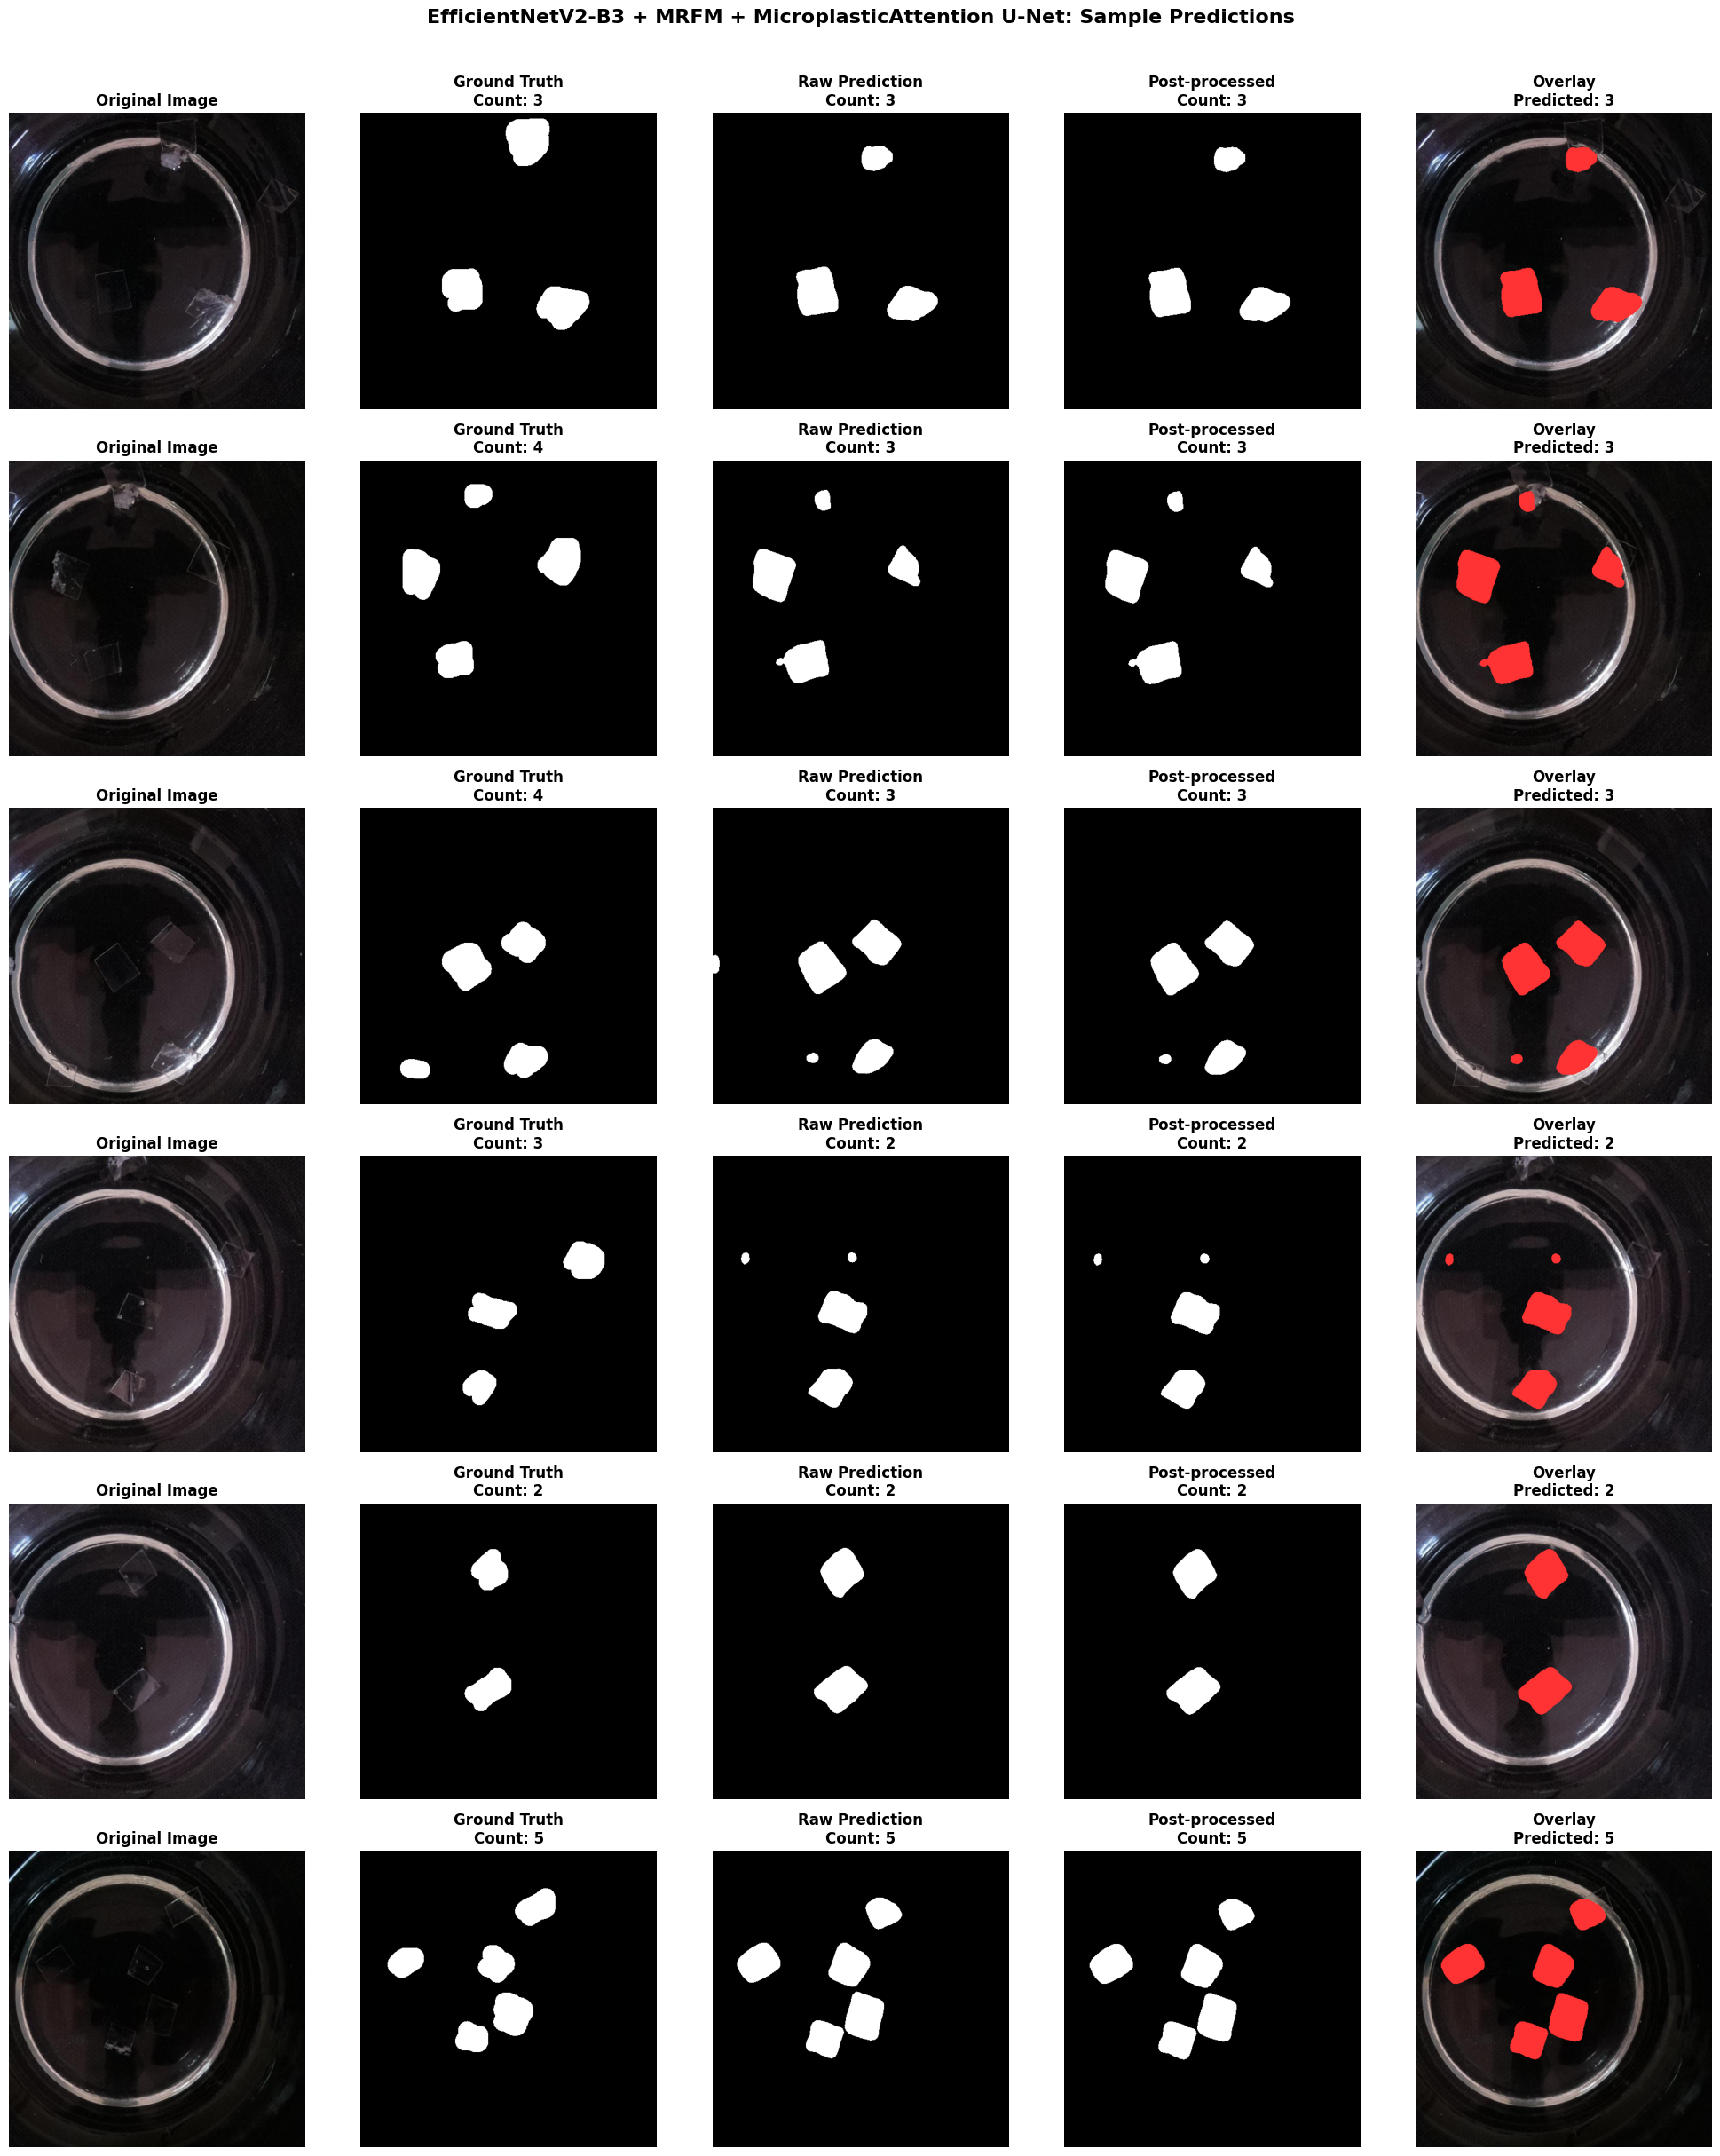

✅ Sample predictions visualization saved

CREATING COMPREHENSIVE VISUALIZATIONS


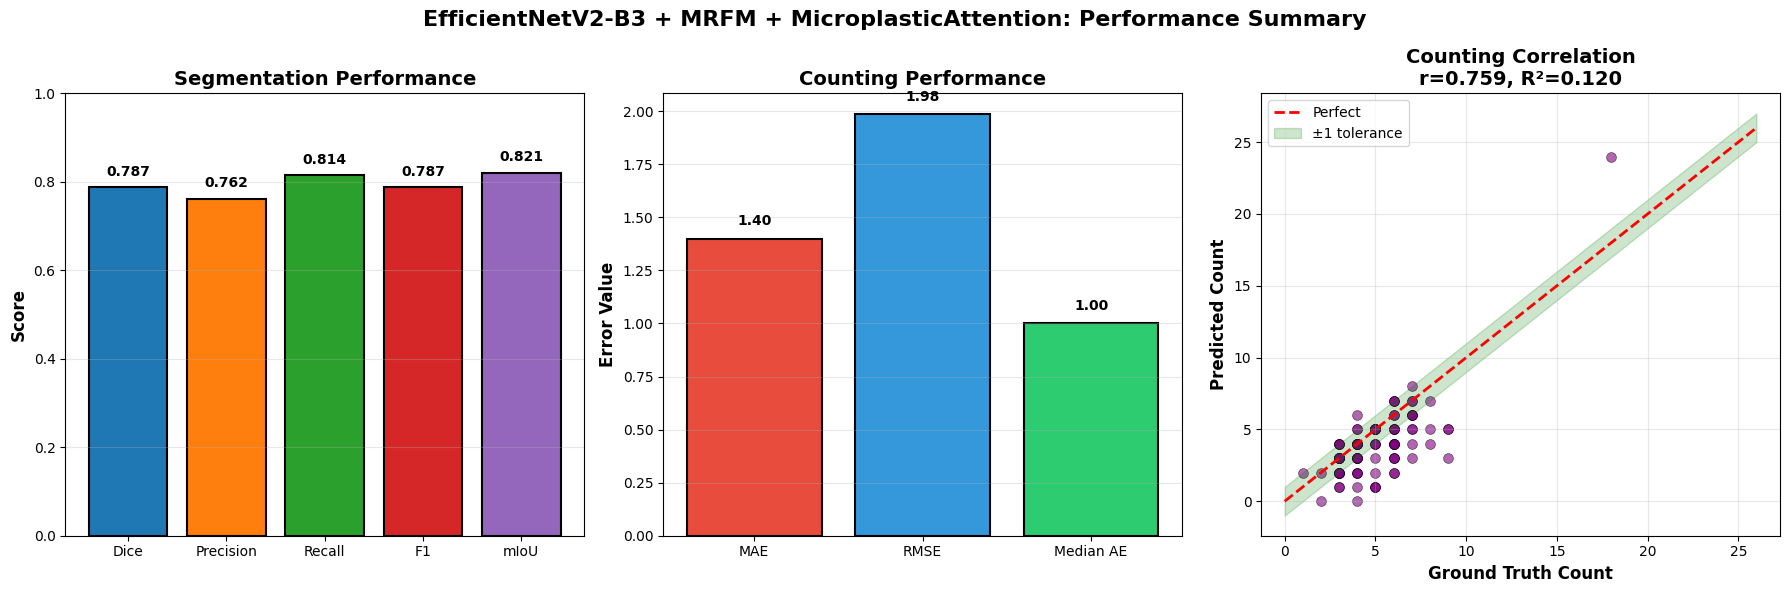

✅ Performance summary visualization saved

SAVING COMPREHENSIVE RESULTS
✅ Results saved to: results_efficientnetv2b3_mrfm_attention_512/
   - comprehensive_results.csv
   - performance_summary.txt
   - performance_summary.png
   - sample_predictions.png

TRAINING AND EVALUATION COMPLETE!

📊 KEY RESULTS:
  Segmentation:
    • Dice = 0.7874
    • Precision = 0.7621
    • Recall = 0.8145
    • mIoU = 0.8207
  Counting:
    • MAE = 1.400
    • RMSE = 1.985
    • Tolerance Acc = 65.0%
    • Pearson r = 0.759
    • R² = 0.120
  Improvement:
    • MAE reduction: -3.7%
    • Tol. Acc gain: -3.0%


In [3]:
# ============================================================================
# CUSTOM LOSS FUNCTIONS
# ============================================================================

# ============================================================================
# CUSTOM LOSS FUNCTIONS - OPTIMIZED FOR SEVERE IMBALANCE
# ============================================================================

def calculate_class_weights(masks):
    """Calculate class weights for imbalanced segmentation."""
    masks_flat = (masks > 0.5).astype(np.uint8).flatten()
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.array([0, 1]),
        y=masks_flat
    )
    return {0: class_weights[0], 1: class_weights[1]}

if len(y_train) > 0:
    class_weights = calculate_class_weights(y_train)
    cw0 = tf.constant(class_weights[0], dtype=tf.float32)
    cw1 = tf.constant(class_weights[1], dtype=tf.float32)
    print(f"Class weights - Background: {cw0:.4f}, Foreground: {cw1:.4f}")
else:
    cw0 = tf.constant(1.0, dtype=tf.float32)
    cw1 = tf.constant(1.0, dtype=tf.float32)


def dice_coefficient(y_true, y_pred, smooth=1e-6):
    """FIXED: Properly handle both (B,H,W) and (B,H,W,1) shapes."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # Squeeze if channel dimension exists
    if len(y_true.shape) == 4:
        y_true = tf.squeeze(y_true, axis=-1)
    if len(y_pred.shape) == 4:
        y_pred = tf.squeeze(y_pred, axis=-1)

    y_true_flat = tf.reshape(y_true, [-1])
    y_pred_flat = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_flat * y_pred_flat)
    union = tf.reduce_sum(y_true_flat) + tf.reduce_sum(y_pred_flat)

    return (2.0 * intersection + smooth) / (union + smooth)


def dice_loss(y_true, y_pred, smooth=1e-6):
    """Dice loss for binary segmentation."""
    return 1.0 - dice_coefficient(y_true, y_pred, smooth)


def focal_loss(y_true, y_pred, alpha=0.25, gamma=2.0):
    """FIXED: Properly handle shapes."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # Squeeze if channel dimension exists
    if len(y_true.shape) == 4:
        y_true = tf.squeeze(y_true, axis=-1)
    if len(y_pred.shape) == 4:
        y_pred = tf.squeeze(y_pred, axis=-1)

    y_pred = tf.clip_by_value(y_pred, K.epsilon(), 1 - K.epsilon())

    pt = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
    alpha_t = tf.where(tf.equal(y_true, 1), alpha, 1 - alpha)

    loss = -alpha_t * tf.pow(1 - pt, gamma) * tf.math.log(pt)
    return tf.reduce_mean(loss)


def tversky_loss(y_true, y_pred, alpha=0.7, beta=0.3, smooth=1e-6):
    """FIXED: Properly handle shapes."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # Squeeze if channel dimension exists
    if len(y_true.shape) == 4:
        y_true = tf.squeeze(y_true, axis=-1)
    if len(y_pred.shape) == 4:
        y_pred = tf.squeeze(y_pred, axis=-1)

    y_true_flat = tf.reshape(y_true, [-1])
    y_pred_flat = tf.reshape(y_pred, [-1])

    true_pos = tf.reduce_sum(y_true_flat * y_pred_flat)
    false_neg = tf.reduce_sum(y_true_flat * (1 - y_pred_flat))
    false_pos = tf.reduce_sum((1 - y_true_flat) * y_pred_flat)

    tversky = (true_pos + smooth) / (true_pos + alpha * false_neg + beta * false_pos + smooth)

    return 1.0 - tversky


def aggressive_imbalance_loss(y_true, y_pred):
    """FIXED: Properly handle shapes."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # Squeeze if channel dimension exists
    if len(y_true.shape) == 4:
        y_true = tf.squeeze(y_true, axis=-1)
    if len(y_pred.shape) == 4:
        y_pred = tf.squeeze(y_pred, axis=-1)

    y_pred = tf.clip_by_value(y_pred, K.epsilon(), 1 - K.epsilon())

    # Dice loss (emphasizes overlap)
    dice = dice_loss(y_true, y_pred)

    # Tversky loss (emphasizes recall)
    tversky = tversky_loss(y_true, y_pred, alpha=0.7, beta=0.3)

    # Focal loss (handles imbalance)
    focal = focal_loss(y_true, y_pred, alpha=0.75, gamma=2.0)

    # Heavily weight shape losses over pixel-wise losses
    total_loss = 5.0 * dice + 3.0 * tversky + 1.0 * focal

    return total_loss


def focal_dice_loss(y_true, y_pred, gamma=2.0, dice_weight=3.0, focal_weight=1.0):
    """FIXED: Properly handle shapes."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # Squeeze if channel dimension exists
    if len(y_true.shape) == 4:
        y_true = tf.squeeze(y_true, axis=-1)
    if len(y_pred.shape) == 4:
        y_pred = tf.squeeze(y_pred, axis=-1)

    focal = focal_loss(y_true, y_pred, alpha=0.75, gamma=gamma)
    dice = dice_loss(y_true, y_pred)

    return focal_weight * focal + dice_weight * dice


def iou_metric(y_true, y_pred, smooth=1e-6):
    """FIXED: Properly handle shapes."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # Squeeze if channel dimension exists
    if len(y_true.shape) == 4:
        y_true = tf.squeeze(y_true, axis=-1)
    if len(y_pred.shape) == 4:
        y_pred = tf.squeeze(y_pred, axis=-1)

    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection

    iou = (intersection + smooth) / (union + smooth)

    return iou


# ============================================================================
# PREDICTION MONITORING CALLBACK
# ============================================================================

class PredictionMonitor(tf.keras.callbacks.Callback):
    """FIXED: Properly preprocess validation data before prediction."""
    def __init__(self, val_data, val_masks):
        super().__init__()
        # Store raw validation data
        self.val_data_raw = val_data[:4]
        self.val_masks = val_masks[:4]

        # Preprocess for EfficientNet
        self.val_data = preprocess_input(self.val_data_raw * 255.0)

    def on_epoch_end(self, epoch, logs=None):
        if epoch % 3 == 0:
            preds = self.model.predict(self.val_data, verbose=0)

            # Handle shape properly
            if len(preds.shape) == 4 and preds.shape[-1] == 1:
                preds = preds.squeeze(-1)

            fg_pixels = (preds > 0.5).sum()
            total_pixels = preds.size
            max_pred = preds.max()
            mean_pred = preds.mean()

            print(f"\n  📊 [Epoch {epoch}] Predictions: max={max_pred:.4f}, mean={mean_pred:.4f}, "
                  f"fg_pixels={fg_pixels:,}/{total_pixels:,} ({fg_pixels/total_pixels*100:.3f}%)")


# =============================================================================
# FIXED EVALUATION CODE
# =============================================================================

def preprocess_test_data(X_test):
    """Preprocess test data the same way as training data."""
    # X_test is in [0, 1] range from loading
    # Convert to [0, 255] then apply EfficientNet preprocessing
    X_test_preprocessed = preprocess_input(X_test * 255.0)
    return X_test_preprocessed


# =============================================================================
# COMPLETE FIXED TRAINING SCRIPT
# =============================================================================

print("\n" + "="*80)
print("BUILDING MODEL WITH FIXES")
print("="*80)

model, backbone = build_efficientnetv2b3_mrfm_attention_unet(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

print(f"✅ Model compiled successfully")
print(f"   Total parameters: {model.count_params():,}")
print(f"   Output shape: {model.output.shape}")  # Should be (None, 512, 512, 1)

# =============================================================================
# TWO-PHASE TRAINING WITH FIXES
# =============================================================================

print("\n" + "="*80)
print("PHASE 1: Training decoder (backbone frozen)")
print("="*80)

backbone.trainable = False

# Compile with aggressive loss and higher learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=aggressive_imbalance_loss,
    metrics=[dice_coefficient, iou_metric]
)

callbacks_phase1 = [
    PredictionMonitor(X_val, y_val),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_dice_coefficient',
        patience=15,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_dice_coefficient',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        mode='max',
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        '/content/efficientnetv2b3_mrfm_attention_phase1.weights.h5',
        monitor='val_dice_coefficient',
        save_best_only=True,
        save_weights_only=True,
        mode='max',
        verbose=1
    ),
    tf.keras.callbacks.CSVLogger(
        '/content/training_log_phase1.csv',
        append=False
    )
]

print(f"\nTraining Phase 1 with {len(X_train)} samples, batch size {BATCH_SIZE}")
history_phase1 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=40,
    callbacks=callbacks_phase1,
    verbose=1
)

# CRITICAL: Check Phase 1 results with PREPROCESSED data
print("\n📊 PHASE 1 RESULTS:")
print(f"   Best Dice: {max(history_phase1.history['val_dice_coefficient']):.4f}")
print(f"   Final Dice: {history_phase1.history['val_dice_coefficient'][-1]:.4f}")

# FIXED: Preprocess training data before prediction check
X_train_preprocessed = preprocess_input(X_train[:4] * 255.0)
train_pred_check = model.predict(X_train_preprocessed, verbose=0)
if len(train_pred_check.shape) == 4 and train_pred_check.shape[-1] == 1:
    train_pred_check = train_pred_check.squeeze(-1)
print(f"   Train pred range: [{train_pred_check.min():.4f}, {train_pred_check.max():.4f}]")
print(f"   Train pred mean: {train_pred_check.mean():.4f}")
print(f"   Train fg pixels: {(train_pred_check > 0.5).sum():,} / {train_pred_check.size:,}")

# PHASE 2: Fine-tune entire model
print("\n" + "="*80)
print("PHASE 2: Fine-tuning entire model")
print("="*80)

backbone.trainable = True
for layer in backbone.layers[:-80]:
    layer.trainable = False

# Freeze BatchNorm
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

print(f"Trainable layers in backbone: {sum([1 for l in backbone.layers if l.trainable])}")

# Recompile with lower LR
optimizer_ft = tf.keras.optimizers.AdamW(
    learning_rate=5e-5,
    weight_decay=1e-5,
    beta_1=0.9,
    beta_2=0.999
)

model.compile(
    optimizer=optimizer_ft,
    loss=focal_dice_loss,
    metrics=[
        dice_coefficient,
        iou_metric,
        'binary_accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

callbacks_phase2 = [
    PredictionMonitor(X_val, y_val),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_dice_coefficient',
        patience=PATIENCE,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_dice_coefficient',
        factor=0.5,
        patience=8,
        min_lr=1e-7,
        mode='max',
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        '/content/efficientnetv2b3_mrfm_attention_final.weights.h5',
        monitor='val_dice_coefficient',
        save_best_only=True,
        save_weights_only=True,
        mode='max',
        verbose=1
    ),
    tf.keras.callbacks.CSVLogger(
        '/content/training_log_phase2.csv',
        append=False
    )
]

print(f"\nTraining Phase 2 with {len(X_train)} samples, batch size {BATCH_SIZE}")
history_phase2 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks_phase2,
    verbose=1,
    initial_epoch=len(history_phase1.history['loss'])
)

print("\n✅ Two-phase training complete!")
print(f"   Best Dice (Phase 2): {max(history_phase2.history['val_dice_coefficient']):.4f}")


# =============================================================================
# FIXED EVALUATION
# =============================================================================

print("\n" + "="*80)
print("EVALUATING BEST MODEL")
print("="*80)

# Reconstruct model
print("Reconstructing model architecture...")
model, backbone = build_efficientnetv2b3_mrfm_attention_unet(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

backbone.trainable = True
for layer in backbone.layers[:-80]:
    layer.trainable = False

for layer in model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

optimizer_ft = tf.keras.optimizers.AdamW(
    learning_rate=5e-5,
    weight_decay=1e-5,
    beta_1=0.9,
    beta_2=0.999
)

model.compile(
    optimizer=optimizer_ft,
    loss=focal_dice_loss,
    metrics=[
        dice_coefficient,
        iou_metric,
        'binary_accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

# Load best weights
print("Loading best weights...")
model.load_weights('/content/efficientnetv2b3_mrfm_attention_final.weights.h5')
print("✅ Model weights loaded successfully")

# CRITICAL FIX: Preprocess test data before prediction
print("Preprocessing test data...")
X_test_preprocessed = preprocess_test_data(X_test)
print(f"Test data preprocessed: shape={X_test_preprocessed.shape}, "
      f"range=[{X_test_preprocessed.min():.2f}, {X_test_preprocessed.max():.2f}]")

# Generate predictions on preprocessed data
print("Generating predictions on test set...")
test_pred_raw = model.predict(X_test_preprocessed, batch_size=BATCH_SIZE, verbose=1)
print(f"Predictions shape: {test_pred_raw.shape}")
print(f"Predictions range: [{test_pred_raw.min():.4f}, {test_pred_raw.max():.4f}]")

# Ground truth counts from masks
gt_counts = test_counts.flatten()
# ============================================================================
# FIXED EVALUATION CODE - Replace the evaluation section in your script
# ============================================================================

# ============================================================================
# SEGMENTATION EVALUATION
# ============================================================================

print("\n" + "="*80)
print("SEGMENTATION PERFORMANCE EVALUATION")
print("="*80)

# Ensure predictions are in correct shape
if len(test_pred_raw.shape) == 4 and test_pred_raw.shape[-1] == 1:
    test_pred_raw = test_pred_raw.squeeze(-1)

# Raw binary segmentation with threshold
seg_threshold = 0.3
y_pred_binary = (test_pred_raw > seg_threshold).astype(np.uint8)

# Ensure y_test is in correct shape
y_test_eval = y_test.copy()
if len(y_test_eval.shape) == 4 and y_test_eval.shape[-1] == 1:
    y_test_eval = y_test_eval.squeeze(-1)

# Calculate global segmentation metrics
seg_metrics = calculate_segmentation_metrics(
    y_test_eval.astype(np.uint8),
    y_pred_binary
)

print(f"{'Metric':<20} {'Value':<10}")
print("-" * 35)
print(f"{'Dice Coefficient':<20} {seg_metrics['dice']:.4f}")
print(f"{'Precision':<20} {seg_metrics['precision']:.4f}")
print(f"{'Recall':<20} {seg_metrics['recall']:.4f}")
print(f"{'F1-score':<20} {seg_metrics['f1']:.4f}")
print(f"{'mIoU':<20} {seg_metrics['miou']:.4f}")
print(f"{'IoU (Foreground)':<20} {seg_metrics['iou_foreground']:.4f}")
print(f"{'IoU (Background)':<20} {seg_metrics['iou_background']:.4f}")


# ============================================================================
# COUNTING EVALUATION
# ============================================================================

print("\n" + "="*80)
print("COUNTING PERFORMANCE EVALUATION")
print("="*80)

# Apply stable post-processing - FIX: Use 'threshold' not 'bin_threshold'
test_pred_processed = stable_postprocessing(test_pred_raw, threshold=0.3)

# 1. Post-processed segmentation-based counting
print("\n=== POST-PROCESSED SEGMENTATION-BASED COUNTING ===")
proc_counts = []
for i in range(len(test_pred_processed)):
    pred_slice = test_pred_processed[i]
    if len(pred_slice.shape) == 3:
        pred_slice = pred_slice.squeeze()
    count = count_particles_cc(pred_slice, use_watershed=True)
    proc_counts.append(count)

proc_counts = np.array(proc_counts)

# FIX: Add missing median_ae, nmae, mape, r2 to calculate_counting_metrics
def calculate_counting_metrics_enhanced(gt_counts, pred_counts, tol=1.0):
    """
    Calculate comprehensive counting metrics with all necessary statistics.

    Parameters:
    -----------
    gt_counts : array-like
        Ground truth particle counts
    pred_counts : array-like
        Predicted particle counts
    tol : float
        Tolerance for accuracy calculation (default=1.0)

    Returns:
    --------
    dict : Dictionary containing all counting metrics
    """
    gt_counts = np.asarray(gt_counts).flatten()
    pred_counts = np.asarray(pred_counts).flatten()

    # Basic regression metrics
    mae = mean_absolute_error(gt_counts, pred_counts)
    rmse = np.sqrt(mean_squared_error(gt_counts, pred_counts))
    bias = np.mean(pred_counts - gt_counts)

    # Median absolute error
    median_ae = np.median(np.abs(pred_counts - gt_counts))

    # Normalized MAE
    mean_gt = np.mean(gt_counts)
    nmae = mae / mean_gt if mean_gt > 0 else 0.0

    # Mean Absolute Percentage Error
    mape = np.mean(np.abs((gt_counts - pred_counts) / (gt_counts + 1e-8))) * 100

    # Pearson correlation
    if len(gt_counts) > 1 and np.std(gt_counts) > 0 and np.std(pred_counts) > 0:
        pearson_r = np.corrcoef(gt_counts, pred_counts)[0, 1]
    else:
        pearson_r = 0.0

    # R-squared
    ss_res = np.sum((gt_counts - pred_counts) ** 2)
    ss_tot = np.sum((gt_counts - np.mean(gt_counts)) ** 2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0.0

    # Tolerance accuracy
    tol_acc = np.mean(np.abs(pred_counts - gt_counts) <= tol) * 100

    return {
        'mae': mae,
        'rmse': rmse,
        'bias': bias,
        'median_ae': median_ae,
        'nmae': nmae,
        'mape_%': mape,
        'pearson_r': pearson_r,
        'r2': r2,
        'tol_acc_%': tol_acc,
        'total_images': len(gt_counts)
    }


def stable_postprocessing(predictions, threshold=0.3):
    """
    FIXED: Apply stable post-processing pipeline.
    Now properly handles the threshold parameter.
    """
    processed = []

    for pred in predictions:
        # Handle shape properly
        if len(pred.shape) == 3 and pred.shape[-1] == 1:
            pred_prob = pred.squeeze(-1)
        else:
            pred_prob = pred.squeeze()

        # Step 1: Fixed threshold
        binary_pred = (pred_prob > threshold).astype(np.uint8)

        if binary_pred.sum() == 0:
            processed.append(np.zeros_like(binary_pred, dtype=np.float32))
            continue

        # Step 2: Remove border objects
        binary_no_border = remove_border_objects(binary_pred, border_width=5)

        if binary_no_border.sum() == 0:
            processed.append(np.zeros_like(binary_no_border, dtype=np.float32))
            continue

        # Step 3: Morphological cleaning
        kernel = np.ones((2, 2), np.uint8)
        cleaned = cv2.morphologyEx(binary_no_border, cv2.MORPH_OPEN, kernel)
        cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)

        if cleaned.sum() == 0:
            processed.append(np.zeros_like(cleaned, dtype=np.float32))
            continue

        # Step 4: Size filtering
        size_filtered = adaptive_min_area_filtering(cleaned, percentile=3)

        if size_filtered.sum() == 0:
            processed.append(np.zeros_like(size_filtered, dtype=np.float32))
            continue

        # Step 5: Confidence filtering
        final_mask = confidence_noise_suppression(size_filtered, pred_prob, threshold=threshold)

        processed.append(final_mask.astype(np.float32))

    # Return with proper shape (N, H, W, 1)
    return np.array(processed)[..., np.newaxis].astype(np.float32)

proc_metrics = calculate_counting_metrics_enhanced(gt_counts, proc_counts, tol=1.0)
print(f"Counting on post-processed predictions:")
print(f"  MAE = {proc_metrics['mae']:.3f}")
print(f"  RMSE = {proc_metrics['rmse']:.3f}")
print(f"  Median AE = {proc_metrics['median_ae']:.3f}")
print(f"  Bias = {proc_metrics['bias']:.3f}")
print(f"  NMAE = {proc_metrics['nmae']:.3f}")
print(f"  MAPE = {proc_metrics['mape_%']:.2f}%")
print(f"  Tolerance Accuracy (±1) = {proc_metrics['tol_acc_%']:.1f}%")
print(f"  Pearson r = {proc_metrics['pearson_r']:.3f}")
print(f"  R² = {proc_metrics['r2']:.3f}")

# 2. Raw segmentation-based counting (for comparison)
print("\n=== RAW SEGMENTATION-BASED COUNTING (for reference) ===")
raw_counts = []
for i in range(len(test_pred_raw)):
    pred_slice = test_pred_raw[i]
    if len(pred_slice.shape) == 3:
        pred_slice = pred_slice.squeeze()
    binary_pred = (pred_slice > 0.3).astype(np.uint8)
    count = count_particles_cc(binary_pred, use_watershed=True)
    raw_counts.append(count)

raw_counts = np.array(raw_counts)

raw_metrics = calculate_counting_metrics_enhanced(gt_counts, raw_counts, tol=1.0)
print(f"Counting on raw predictions (threshold=0.3):")
print(f"  MAE = {raw_metrics['mae']:.3f}")
print(f"  Tolerance Accuracy (±1) = {raw_metrics['tol_acc_%']:.1f}%")

# Improvement analysis
print("\n=== IMPROVEMENT ANALYSIS ===")
if raw_metrics['mae'] > 0:
    mae_improvement = ((raw_metrics['mae'] - proc_metrics['mae']) / raw_metrics['mae']) * 100
else:
    mae_improvement = 0.0
tol_acc_improvement = proc_metrics['tol_acc_%'] - raw_metrics['tol_acc_%']

print(f"Post-processing vs raw segmentation:")
print(f"  MAE reduction: {mae_improvement:+.1f}%")
print(f"  Tolerance accuracy improvement: {tol_acc_improvement:+.1f}%")


# ============================================================================
# CREATE RESULTS DIRECTORY
# ============================================================================

os.makedirs('results_efficientnetv2b3_mrfm_attention_512', exist_ok=True)


# ============================================================================
# VISUALIZE SAMPLE PREDICTIONS
# ============================================================================

print("\n" + "="*80)
print("VISUALIZING SAMPLE PREDICTIONS")
print("="*80)

# Sample visualizations
num_samples = min(6, len(X_test))
sample_indices = list(range(num_samples))

if len(sample_indices) > 0:
    fig, axes = plt.subplots(len(sample_indices), 5, figsize=(20, 4*len(sample_indices)))
    if len(sample_indices) == 1:
        axes = axes.reshape(1, -1)

    for idx, sample_idx in enumerate(sample_indices):
        # Original RGB image
        img_display = X_test[sample_idx].copy()
        if len(img_display.shape) == 3 and img_display.shape[-1] == 3:
            img_min = img_display.min()
            img_max = img_display.max()
            if img_max > img_min:
                img_display = (img_display - img_min) / (img_max - img_min)
            img_display = np.clip(img_display, 0, 1)

        axes[idx, 0].imshow(img_display)
        axes[idx, 0].set_title('Original Image', fontweight='bold')
        axes[idx, 0].axis('off')

        # Ground truth mask
        gt_mask = y_test[sample_idx].copy()
        if len(gt_mask.shape) == 3:
            gt_mask = gt_mask.squeeze()
        axes[idx, 1].imshow(gt_mask, cmap='gray')
        gt_count = int(gt_counts[sample_idx]) if sample_idx < len(gt_counts) else 0
        axes[idx, 1].set_title(f'Ground Truth\nCount: {gt_count}', fontweight='bold')
        axes[idx, 1].axis('off')

        # Raw prediction
        raw_pred = test_pred_raw[sample_idx].copy()
        if len(raw_pred.shape) == 3:
            raw_pred = raw_pred.squeeze()
        raw_pred_binary = (raw_pred > 0.3).astype(np.uint8)
        axes[idx, 2].imshow(raw_pred_binary, cmap='gray')
        raw_count = raw_counts[sample_idx] if sample_idx < len(raw_counts) else 0
        axes[idx, 2].set_title(f'Raw Prediction\nCount: {raw_count}', fontweight='bold')
        axes[idx, 2].axis('off')

        # Processed prediction
        proc_pred = test_pred_processed[sample_idx].copy()
        if len(proc_pred.shape) == 3:
            proc_pred = proc_pred.squeeze()
        axes[idx, 3].imshow(proc_pred, cmap='gray')
        proc_count = proc_counts[sample_idx] if sample_idx < len(proc_counts) else 0
        axes[idx, 3].set_title(f'Post-processed\nCount: {proc_count}', fontweight='bold')
        axes[idx, 3].axis('off')

        # Overlay
        overlay = img_display.copy()
        if len(overlay.shape) == 2:
            overlay = np.stack([overlay]*3, axis=-1)
        mask_overlay = proc_pred > 0.5
        overlay[mask_overlay, 0] = 1.0
        overlay[mask_overlay, 1] = 0.2
        overlay[mask_overlay, 2] = 0.2
        axes[idx, 4].imshow(overlay)
        axes[idx, 4].set_title(f'Overlay\nPredicted: {proc_count}', fontweight='bold')
        axes[idx, 4].axis('off')

    plt.suptitle('EfficientNetV2-B3 + MRFM + MicroplasticAttention U-Net: Sample Predictions',
                 fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('results_efficientnetv2b3_mrfm_attention_512/sample_predictions.png',
                dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Sample predictions visualization saved")


# ============================================================================
# COMPREHENSIVE VISUALIZATIONS
# ============================================================================

print("\n" + "="*80)
print("CREATING COMPREHENSIVE VISUALIZATIONS")
print("="*80)

# Performance comparison chart
fig = plt.figure(figsize=(18, 6))

# Subplot 1: Segmentation metrics
ax1 = plt.subplot(1, 3, 1)
metrics_names = ['Dice', 'Precision', 'Recall', 'F1', 'mIoU']
metrics_values = [seg_metrics['dice'], seg_metrics['precision'],
                  seg_metrics['recall'], seg_metrics['f1'], seg_metrics['miou']]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
bars = ax1.bar(metrics_names, metrics_values, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
ax1.set_title('Segmentation Performance', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 1.0)
ax1.grid(True, alpha=0.3, axis='y')

for bar, value in zip(bars, metrics_values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 0.02,
             f'{value:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Subplot 2: Counting metrics
ax2 = plt.subplot(1, 3, 2)
count_names = ['MAE', 'RMSE', 'Median AE']
count_values = [proc_metrics['mae'], proc_metrics['rmse'], proc_metrics['median_ae']]
bars2 = ax2.bar(count_names, count_values, color=['#e74c3c', '#3498db', '#2ecc71'],
                edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Error Value', fontsize=12, fontweight='bold')
ax2.set_title('Counting Performance', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

for bar, value in zip(bars2, count_values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height + 0.05,
             f'{value:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Subplot 3: Correlation plot
ax3 = plt.subplot(1, 3, 3)
if len(gt_counts) > 0 and len(proc_counts) > 0:
    max_val = max(max(gt_counts), max(proc_counts)) + 2

    ax3.scatter(gt_counts, proc_counts, alpha=0.6, s=50, color='purple',
                edgecolors='black', linewidth=0.5)
    ax3.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect')
    ax3.fill_between([0, max_val], [-1, max_val-1], [1, max_val+1],
                     alpha=0.2, color='green', label='±1 tolerance')

    ax3.set_xlabel('Ground Truth Count', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Predicted Count', fontsize=12, fontweight='bold')
    ax3.set_title(f'Counting Correlation\nr={proc_metrics["pearson_r"]:.3f}, R²={proc_metrics["r2"]:.3f}',
                  fontsize=14, fontweight='bold')
    ax3.grid(True, alpha=0.3)
    ax3.legend(loc='upper left', fontsize=10)

plt.suptitle('EfficientNetV2-B3 + MRFM + MicroplasticAttention: Performance Summary',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('results_efficientnetv2b3_mrfm_attention_512/performance_summary.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("✅ Performance summary visualization saved")


# ============================================================================
# SAVE COMPREHENSIVE RESULTS
# ============================================================================

print("\n" + "="*80)
print("SAVING COMPREHENSIVE RESULTS")
print("="*80)

# Create comprehensive results dataframe
results_df = pd.DataFrame({
    'Image_Index': range(len(gt_counts)),
    'GT_Count': gt_counts,
    'Raw_Count': raw_counts,
    'Processed_Count': proc_counts,
    'Raw_AE': np.abs(raw_counts - gt_counts),
    'Processed_AE': np.abs(proc_counts - gt_counts),
    'Within_Tol_Raw': np.abs(raw_counts - gt_counts) <= 1,
    'Within_Tol_Processed': np.abs(proc_counts - gt_counts) <= 1
})

results_df.to_csv('results_efficientnetv2b3_mrfm_attention_512/comprehensive_results.csv', index=False)

# Save performance summary
with open('results_efficientnetv2b3_mrfm_attention_512/performance_summary.txt', 'w') as f:
    f.write("="*80 + "\n")
    f.write("EFFICIENTNETV2-B3 + MRFM + MICROPLASTIC ATTENTION U-NET\n")
    f.write("PERFORMANCE SUMMARY\n")
    f.write("="*80 + "\n\n")

    f.write("ARCHITECTURE\n")
    f.write("-" * 40 + "\n")
    f.write("  - Backbone: EfficientNetV2-B3 (ImageNet pretrained)\n")
    f.write("  - Fusion: Multi-Resolution Fusion Module (MRFM)\n")
    f.write("  - Attention: Stage-adaptive MicroplasticAttention\n")
    f.write("    • Early stages: Edge Attention\n")
    f.write("    • Middle stage: Coordinate Attention\n")
    f.write("    • Deep stages: Channel + Spatial Attention\n")
    f.write("  - Input: 512×512×3 (RGB + CLAHE)\n")
    f.write("  - Training: Two-phase (frozen → fine-tuned)\n\n")

    f.write("SEGMENTATION PERFORMANCE\n")
    f.write("-" * 40 + "\n")
    f.write(f"  Dice Coefficient = {seg_metrics['dice']:.4f}\n")
    f.write(f"  Precision = {seg_metrics['precision']:.4f}\n")
    f.write(f"  Recall = {seg_metrics['recall']:.4f}\n")
    f.write(f"  F1-score = {seg_metrics['f1']:.4f}\n")
    f.write(f"  mIoU = {seg_metrics['miou']:.4f}\n")
    f.write(f"  IoU (Foreground) = {seg_metrics['iou_foreground']:.4f}\n")
    f.write(f"  IoU (Background) = {seg_metrics['iou_background']:.4f}\n\n")

    f.write("COUNTING PERFORMANCE\n")
    f.write("-" * 40 + "\n")
    f.write(f"  MAE = {proc_metrics['mae']:.3f}\n")
    f.write(f"  RMSE = {proc_metrics['rmse']:.3f}\n")
    f.write(f"  Median AE = {proc_metrics['median_ae']:.3f}\n")
    f.write(f"  Bias = {proc_metrics['bias']:.3f}\n")
    f.write(f"  NMAE = {proc_metrics['nmae']:.3f}\n")
    f.write(f"  MAPE = {proc_metrics['mape_%']:.2f}%\n")
    f.write(f"  Pearson r = {proc_metrics['pearson_r']:.3f}\n")
    f.write(f"  R² = {proc_metrics['r2']:.3f}\n")
    f.write(f"  Tolerance Acc (±1) = {proc_metrics['tol_acc_%']:.1f}%\n\n")

    f.write("IMPROVEMENT OVER RAW\n")
    f.write("-" * 40 + "\n")
    f.write(f"  MAE reduction: {mae_improvement:+.1f}%\n")
    f.write(f"  Tol. Acc improvement: {tol_acc_improvement:+.1f}%\n\n")

    f.write("SAMPLE STATISTICS\n")
    f.write("-" * 40 + "\n")
    f.write(f"  Total test images: {len(gt_counts)}\n")
    f.write(f"  Mean GT count: {np.mean(gt_counts):.2f}\n")
    f.write(f"  Mean predicted count: {np.mean(proc_counts):.2f}\n")
    f.write(f"  GT count range: [{np.min(gt_counts)}, {np.max(gt_counts)}]\n")
    f.write(f"  Predicted count range: [{np.min(proc_counts)}, {np.max(proc_counts)}]\n")

print("✅ Results saved to: results_efficientnetv2b3_mrfm_attention_512/")
print("   - comprehensive_results.csv")
print("   - performance_summary.txt")
print("   - performance_summary.png")
print("   - sample_predictions.png")


# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "="*80)
print("TRAINING AND EVALUATION COMPLETE!")
print("="*80)
print(f"\n📊 KEY RESULTS:")
print(f"  Segmentation:")
print(f"    • Dice = {seg_metrics['dice']:.4f}")
print(f"    • Precision = {seg_metrics['precision']:.4f}")
print(f"    • Recall = {seg_metrics['recall']:.4f}")
print(f"    • mIoU = {seg_metrics['miou']:.4f}")
print(f"  Counting:")
print(f"    • MAE = {proc_metrics['mae']:.3f}")
print(f"    • RMSE = {proc_metrics['rmse']:.3f}")
print(f"    • Tolerance Acc = {proc_metrics['tol_acc_%']:.1f}%")
print(f"    • Pearson r = {proc_metrics['pearson_r']:.3f}")
print(f"    • R² = {proc_metrics['r2']:.3f}")
print(f"  Improvement:")
print(f"    • MAE reduction: {mae_improvement:+.1f}%")
print(f"    • Tol. Acc gain: {tol_acc_improvement:+.1f}%")
print("="*80)